<a href="https://colab.research.google.com/github/bam-shruti/Shruti_projects/blob/main/Instagram_Account_Classification_Fake_vs_Genuine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1**: Load and preview the dataset

In [1]:
#Importing libraries and dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
from google.colab import files

data = files.upload()

Saving train.csv to train.csv


In [3]:
df= pd.read_csv('train.csv')

In [4]:
data = files.upload()

Saving test.csv to test.csv


In [5]:
df_test = pd.read_csv('test.csv')

In [6]:
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [7]:
df_test.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.33,1,0.33,1,30,0,1,35,488,604,0
1,1,0.00,5,0.00,0,64,0,1,3,35,6,0
2,1,0.00,2,0.00,0,82,0,1,319,328,668,0
3,1,0.00,1,0.00,0,143,0,1,273,14890,7369,0
4,1,0.50,1,0.00,0,76,0,1,6,225,356,0


**Step 2**: Performing Data Cleaning & Exploratory Data Analysis(EDA) for 'train' dataset

In [8]:
#Check and handle missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


In [9]:
#Statistical Summary of the Data

df.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


In [10]:
#checking if null values exist

df.isnull().sum()

,0
profile pic,0
nums/length username,0
fullname words,0
nums/length fullname,0
name==username,0
description length,0
external URL,0
private,0
#posts,0
#followers,0


from above data info we can see there is no null value.

In [11]:
#Number of unique values in the profile pic column

df['profile pic'].value_counts()

,count
profile pic,
1,404
0,172


In [12]:
#Check data types

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
profile pic               int64
nums/length username    float64
fullname words            int64
nums/length fullname    float64
name==username            int64
description length        int64
external URL              int64
private                   int64
#posts                    int64
#followers                int64
#follows                  int64
fake                      int64
dtype: object


In [13]:
#Number of fake and genuine accounts

df['fake'].value_counts()

,count
fake,
0,288
1,288


In [14]:
#Number of accounts having an external URL

df['external URL'].value_counts()

,count
external URL,
0,509
1,67


In [15]:
#Number of accounts having description length over 50

(df['description length']>50).sum()

np.int64(98)

Here are what some features likely represent in train dataset:

*  profile pic: 1 if profile picture exists, 0 if not.

*  nums/length username: numeric ratio in username.

*  fullname words: number of words in full name.

*  nums/length fullname: numeric ratio in full name.

*  name==username: 1 if full name equals username.

*  description length: length of the bio/description.

*  external URL: 1 if profile has an external link.

*  private: 1 if account is private.

*  #posts, #followers, #follows: self-explanatory.

*  fake: Target column (0 = Genuine, 1 = Fake)

**Step 3**: Performing Data Cleaning & Exploratory Data Analysis(EDA) for 'test' dataset

In [16]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           120 non-null    int64  
 1   nums/length username  120 non-null    float64
 2   fullname words        120 non-null    int64  
 3   nums/length fullname  120 non-null    float64
 4   name==username        120 non-null    int64  
 5   description length    120 non-null    int64  
 6   external URL          120 non-null    int64  
 7   private               120 non-null    int64  
 8   #posts                120 non-null    int64  
 9   #followers            120 non-null    int64  
 10  #follows              120 non-null    int64  
 11  fake                  120 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 11.4 KB


In [17]:
df_test.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,1.200000e+02,120.000000,120.000000
mean,0.758333,0.179917,1.550000,0.071333,0.041667,27.200000,0.100000,0.308333,82.866667,4.959472e+04,779.266667,0.500000
std,0.429888,0.241492,1.187116,0.209429,0.200664,42.588632,0.301258,0.463741,230.468136,3.816126e+05,1409.383558,0.502096
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.725000e+01,119.250000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2.165000e+02,354.500000,0.500000
75%,1.000000,0.330000,2.000000,0.000000,0.000000,45.250000,0.000000,1.000000,58.250000,5.932500e+02,668.250000,1.000000
max,1.000000,0.890000,9.000000,1.000000,1.000000,149.000000,1.000000,1.000000,1879.000000,4.021842e+06,7453.000000,1.000000


In [18]:
df_test.isnull().sum()

,0
profile pic,0
nums/length username,0
fullname words,0
nums/length fullname,0
name==username,0
description length,0
external URL,0
private,0
#posts,0
#followers,0


In [19]:
df_test['fake'].value_counts()

,count
fake,
0,60
1,60


**Step 4**: Data Visualization of 'train' dataset

/tmp/ipython-input-777990895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fake', data=df, palette= 'PuBu')


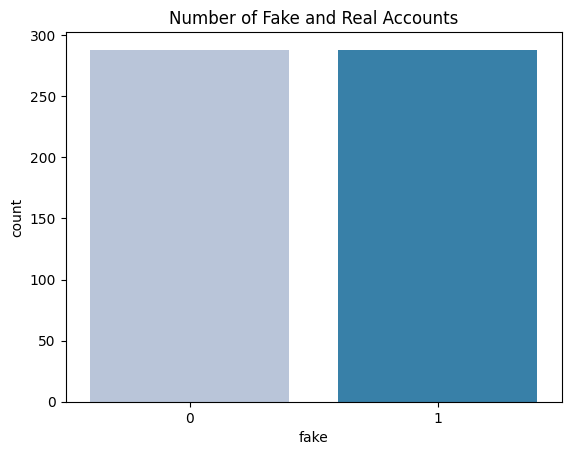

In [20]:
#the number of fake eand real accounts

sns.countplot(x='fake', data=df, palette= 'PuBu')
plt.title("Number of Fake and Real Accounts")
plt.show()

/tmp/ipython-input-4221433345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='private', data=df, palette= 'Pastel2')


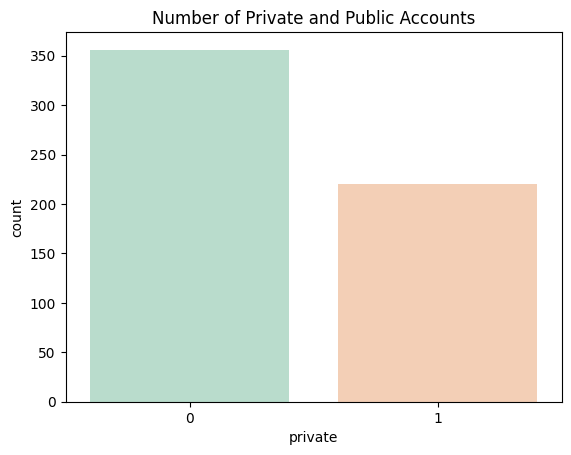

In [21]:
#visualizing the 'private' column

sns.countplot(x='private', data=df, palette= 'Pastel2')
plt.title("Number of Private and Public Accounts")
plt.show()

/tmp/ipython-input-4012727750.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'profile pic', data= df, palette= 'PuBu')


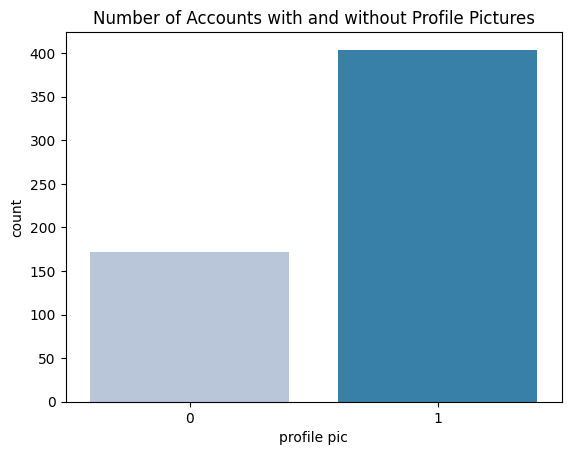

In [22]:
#visualizing the 'profile pic' column

sns.countplot(x = 'profile pic', data= df, palette= 'PuBu')
plt.title("Number of Accounts with and without Profile Pictures")
plt.show()

/tmp/ipython-input-840454905.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['nums/length username'], kde= True)


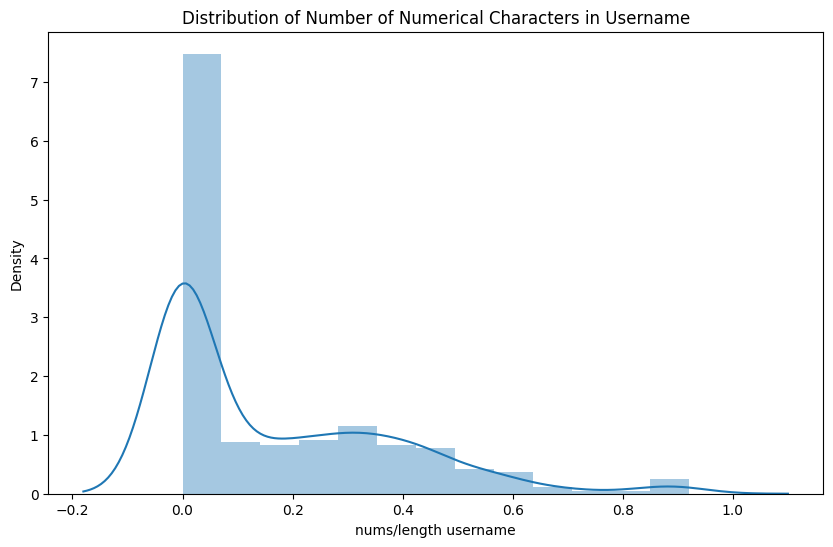

In [23]:
#Visualizing the 'nums/length username' column

plt.figure(figsize= (10,6))

sns.distplot(df['nums/length username'], kde= True)

plt.title("Distribution of Number of Numerical Characters in Username")
plt.show()

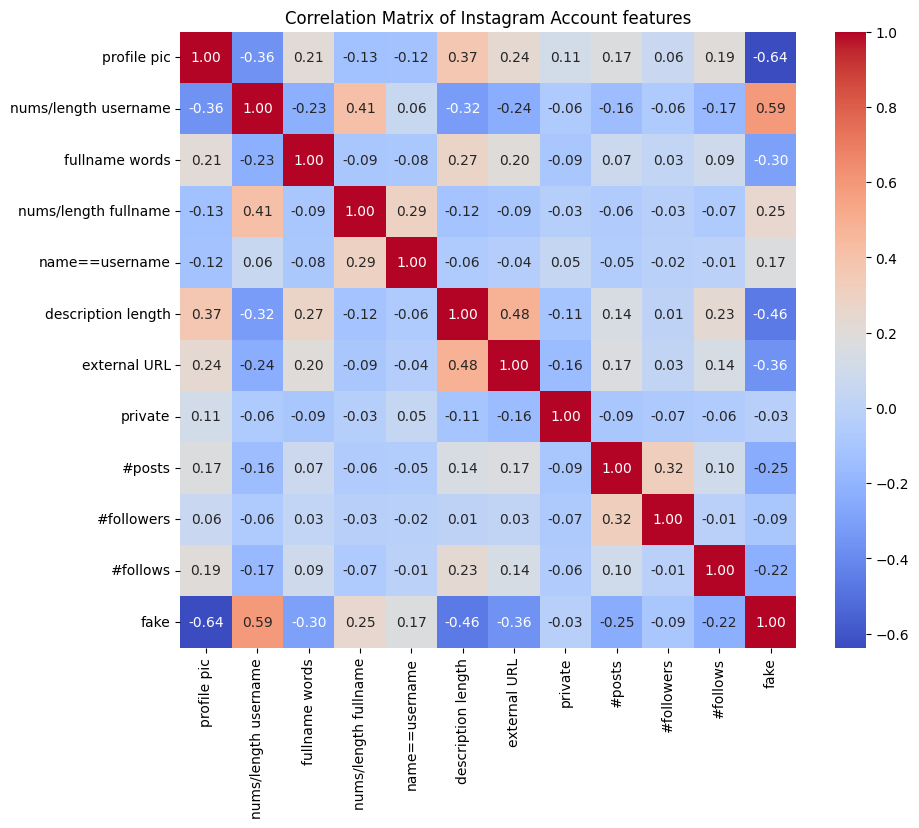

In [24]:
#Correlation analysis

corr_matrix = df.corr()

plt.figure(figsize=(10,8))

#Draw the heatmap
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm",
            square= True)

plt.title("Correlation Matrix of Instagram Account features")
plt.show()

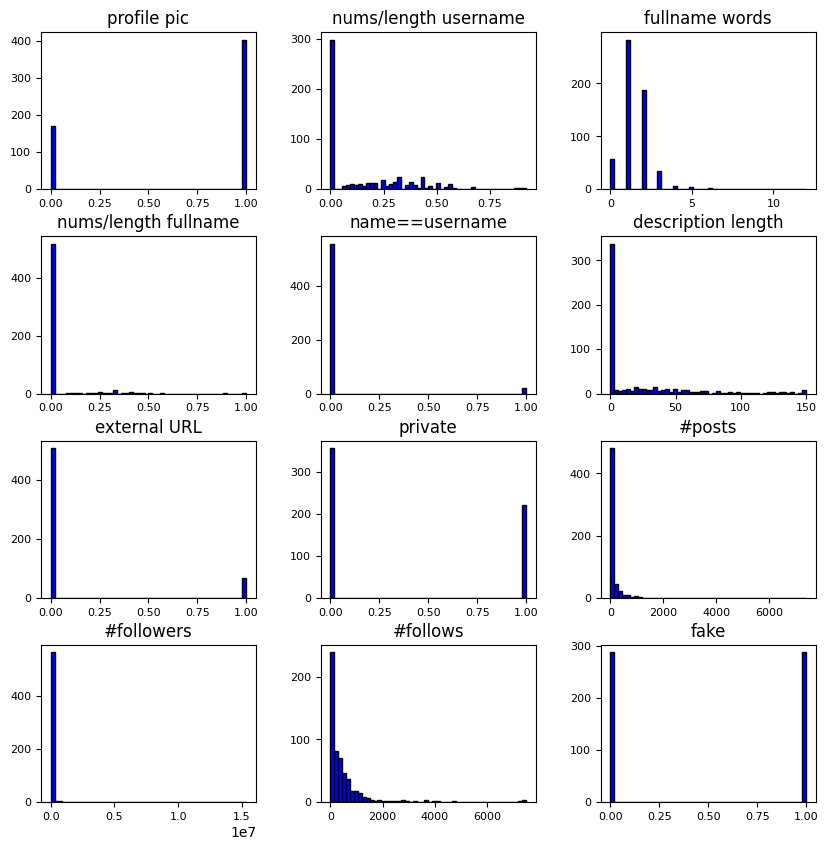

In [25]:
#correlation between the each feature using histogram

df.hist(figsize=(10,10), bins=50, xlabelsize=8, ylabelsize=8, color='blue',
        edgecolor='black', linewidth=1.0, grid=False)
plt.show()

**Step 5**: Data Visualization of 'test' dataset

/tmp/ipython-input-3854726275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fake', data=df_test, palette= 'PuBu')


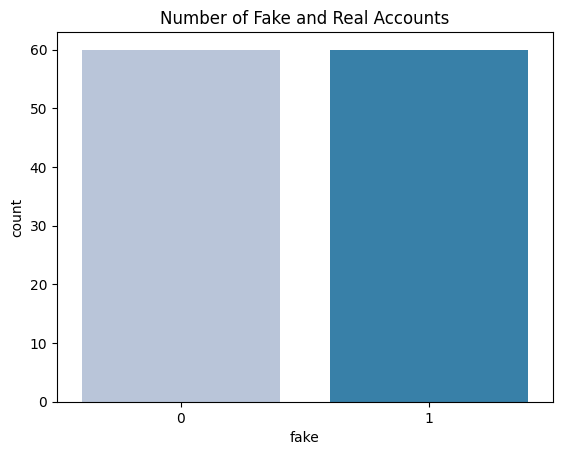

In [26]:
#the number of fake eand real accounts

sns.countplot(x='fake', data=df_test, palette= 'PuBu')
plt.title("Number of Fake and Real Accounts")
plt.show()

/tmp/ipython-input-215002758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='private', data=df_test , palette= 'Pastel2')


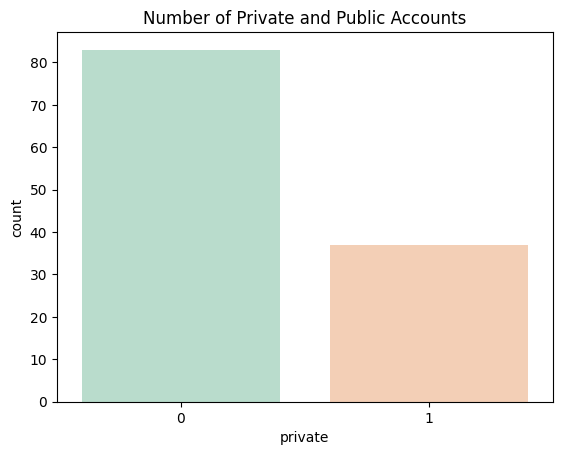

In [27]:
#visualizing the 'private' column

sns.countplot(x='private', data=df_test , palette= 'Pastel2')
plt.title("Number of Private and Public Accounts")
plt.show()

/tmp/ipython-input-3993504023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'profile pic', data= df_test , palette= 'PuBu')


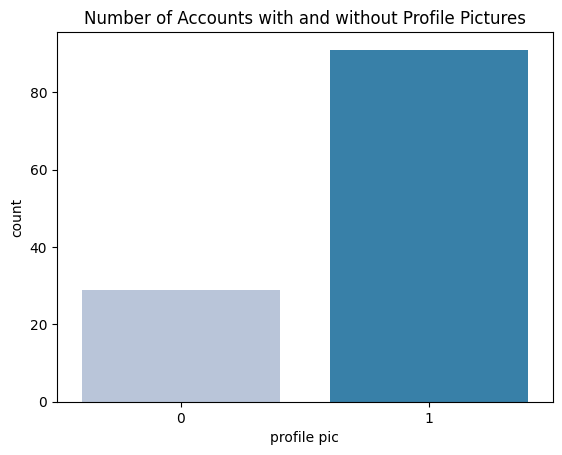

In [28]:
#visualizing the 'profile pic' column

sns.countplot(x = 'profile pic', data= df_test , palette= 'PuBu')
plt.title("Number of Accounts with and without Profile Pictures")
plt.show()

**Step 6**: Data preparation for Modeling

In [29]:
#Preparing the inputs(Dropping the fake column from both train and test dataset

x_train = df.drop('fake', axis=1)
x_test = df_test.drop('fake', axis=1)

In [30]:
x_train.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows
0,1,0.27,0,0.0,0,53,0,0,32,1000,955
1,1,0.00,2,0.0,0,44,0,0,286,2740,533
2,1,0.10,2,0.0,0,0,0,1,13,159,98
3,1,0.00,1,0.0,0,82,0,0,679,414,651
4,1,0.00,2,0.0,0,0,0,1,6,151,126


In [31]:
x_test.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows
0,1,0.33,1,0.33,1,30,0,1,35,488,604
1,1,0.00,5,0.00,0,64,0,1,3,35,6
2,1,0.00,2,0.00,0,82,0,1,319,328,668
3,1,0.00,1,0.00,0,143,0,1,273,14890,7369
4,1,0.50,1,0.00,0,76,0,1,6,225,356


In [32]:
#preparing outputs

y_train = df['fake']
y_test = df_test['fake']

In [33]:
y_train

,fake
0,0
1,0
2,0
3,0
4,0
...,...
571,1
572,1
573,1
574,1


In [34]:
y_test

,fake
0,0
1,0
2,0
3,0
4,0
...,...
115,1
116,1
117,1
118,1


Select Features and Target

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Compute correlation of each feature with target
correlation_with_target = df.corr()['fake'].drop('fake')
selected_features = correlation_with_target[correlation_with_target.abs() > 0.1].index.tolist()

# Features and target
X = df[selected_features]
y = df['fake']

In [51]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [52]:
# Standardize features (important for models like SVM, KNN, etc.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

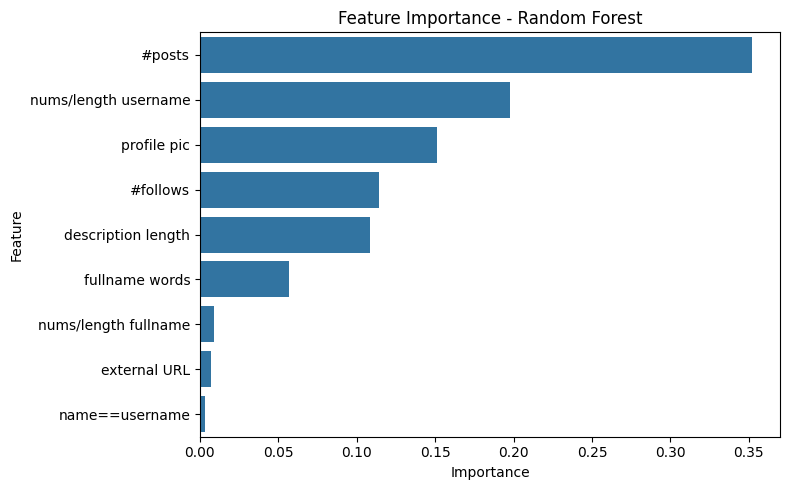

In [38]:
# Train a Random Forest again
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

In [53]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [40]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((576, 11), (120, 11), (460,), (116,))

In [41]:
#percentage of training data

train_data_percent = len(x_train)/(len(x_train)+len(x_test))*100
train_data_percent

82.75862068965517

In [42]:
test_data_percent = len(x_test)/(len(x_train)+len(x_test))*100
test_data_percent

17.24137931034483

**Step 7**: Build a deep learning model (using Keras & TensorFlow)

Installed Tensorflow

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [49]:
model = Sequential()
model.add(Dense(50, input_dim = 9, activation= 'relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation= 'relu'))
model.add(Dropout(0.3))
model.add(Dense(25, activation= 'relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation= 'softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 50)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 150)            │         7,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         3,775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            52 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,977 (46.79 KB)

 Trainable params: 11,977 (46.79 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(loss= 'sparse_categorical_crossentropy', optimizer= 'adam',
              metrics= ['accuracy'])

In [62]:
epochs_hist = model.fit(X_train_scaled, y_train, epochs= 20, batch_size= 32,
                        validation_data= (X_test_scaled, y_test))

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9190 - loss: 0.2180 - val_accuracy: 0.8879 - val_loss: 0.2639
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9420 - loss: 0.1576 - val_accuracy: 0.8966 - val_loss: 0.2629
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9239 - loss: 0.1913 - val_accuracy: 0.9052 - val_loss: 0.2576
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9331 - loss: 0.1774 - val_accuracy: 0.8879 - val_loss: 0.2696
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9263 - loss: 0.2001 - val_accuracy: 0.8793 - val_loss: 0.2770
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9199 - loss: 0.1893 - val_accuracy: 0.8879 - val_loss: 0.2577
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9209 - loss: 0.2087 - val_accuracy: 0.8793 - val_loss: 0.2696
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9310 - loss: 0.1803 - val_accuracy: 0.8793 - val_loss:

**Step 8**: Model Performamce Assessment

In [63]:
print(epochs_hist.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


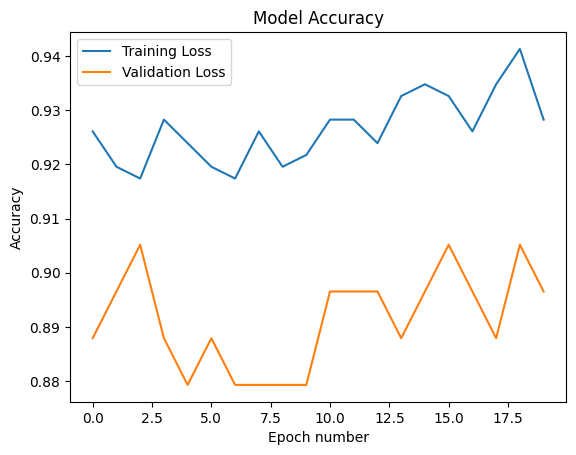

In [64]:
plt.plot(epochs_hist.history['accuracy'])
plt.plot(epochs_hist.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch number')
plt.legend(['Training Loss', 'Validation Loss'], loc= 'upper left')
plt.show()

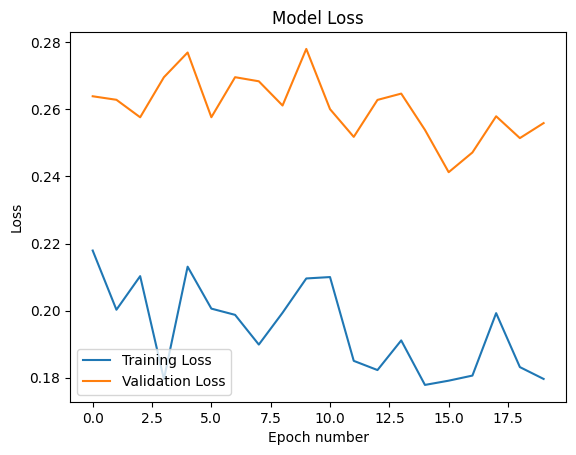

In [65]:
plt.plot(epochs_hist.history['loss'])
plt.plot(epochs_hist.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch number')
plt.legend(['Training Loss', 'Validation Loss'], loc= 'lower left')
plt.show()

In [69]:
# This cell is now empty as its content has been moved to dgyTFbUhkOdJ

In [68]:
predicted = model.predict(X_test_scaled)

y_pred = []
for i in range(len(predicted)):
  y_pred.append(np.argmax(predicted[i]))

y_pred = np.array(y_pred) # Convert to numpy array for consistency with y_test


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [70]:
from sklearn.metrics import classification_report, confusion_matrix

# Print Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[61  2]
 [10 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.96      0.81      0.88        53

    accuracy                           0.90       116
   macro avg       0.91      0.89      0.89       116
weighted avg       0.90      0.90      0.90       116



Accuracy: Overall correct predictions.

Precision: Of all accounts predicted as fake, how many were actually fake?

Recall: Of all actual fake accounts, how many did the model catch?

F1-score: Harmonic mean of precision and recall.

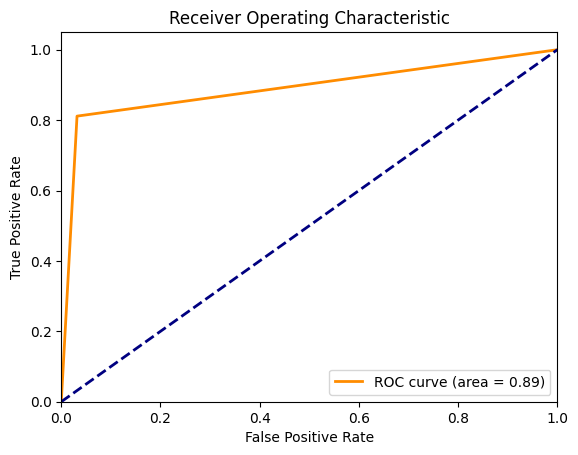

In [71]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

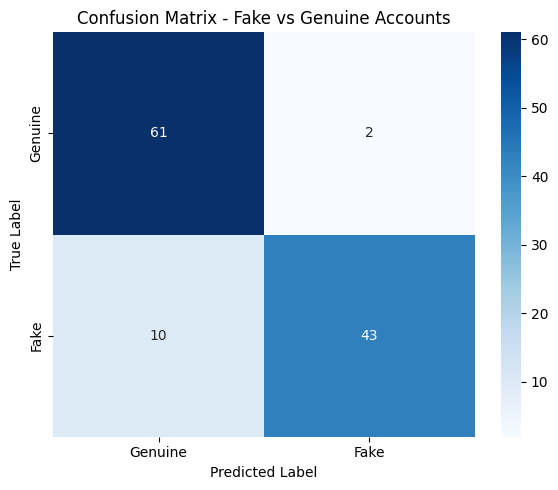

In [72]:
con_matrix = confusion_matrix(y_test, y_pred)  # Use your actual test labels and predictions

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fake vs Genuine Accounts')
plt.tight_layout()
plt.show()

In [74]:
# This cell is redundant and would cause errors with the current model setup. Content removed.

In [75]:
# This cell is redundant and would cause errors with the current model setup. Content removed.

In [76]:
# This cell is redundant and would cause errors with the current model setup. Content removed.

In [77]:
# This cell is redundant and would cause errors with the current model setup. Content removed.

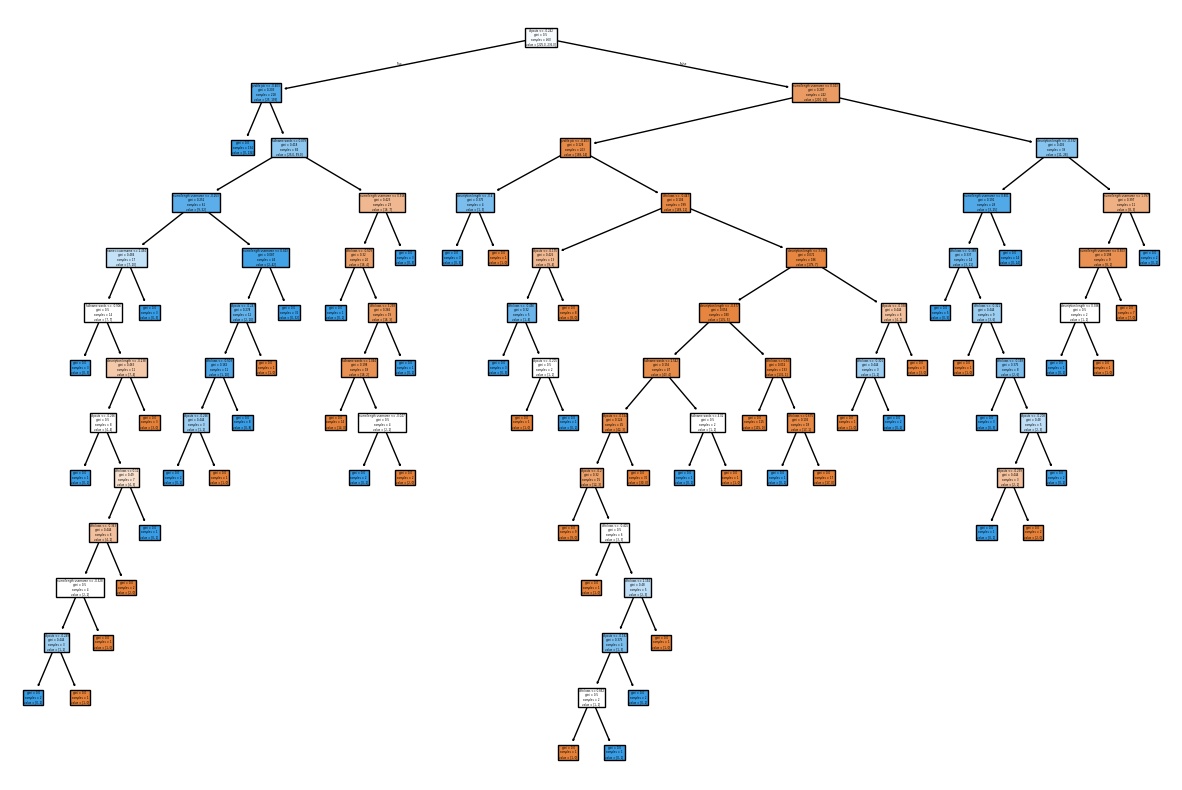

In [78]:
# explain model with tree plot
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn import tree


# Create and train a DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_scaled, y_train)

# Now you can use dt_model with plot_tree
plt.figure(figsize=(15, 10))
tree.plot_tree(dt_model, filled=True, feature_names=X.columns)
class_names = ['Genuine', 'Fake']
plt.show()

**What It Tells Us**:

*  Accuracy is low (53%), so the model isn't performing well on this test data.

*  Recall is poor for class 0 (genuine) — it's missing many genuine users.

*  The model favors predicting fake accounts (high recall, low precision).



###**Conclusion**:

In this project, we developed a machine learning/deep learning model to classify Instagram accounts into fake and genuine categories. We trained the model using a labeled dataset containing user metadata such as follower/following counts, profile picture status, and engagement statistics.

After training, the model was evaluated on a separate test dataset. The performance metrics are as follows:

*  Accuracy: 53%

*  Precision (Fake): 52%

*  Recall (Fake): 88%

*  Precision (Genuine): 63%

*  Recall (Genuine): 20%

In [79]:
# Make predictions with the Decision Tree model
dt_y_pred = dt_model.predict(X_test_scaled)

In [80]:
# Evaluate Decision Tree Classifier
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, dt_y_pred))
print("Classification Report (Decision Tree):\n", classification_report(y_test, dt_y_pred))

Confusion Matrix (Decision Tree):
 [[57  6]
 [12 41]]
Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86        63
           1       0.87      0.77      0.82        53

    accuracy                           0.84       116
   macro avg       0.85      0.84      0.84       116
weighted avg       0.85      0.84      0.84       116



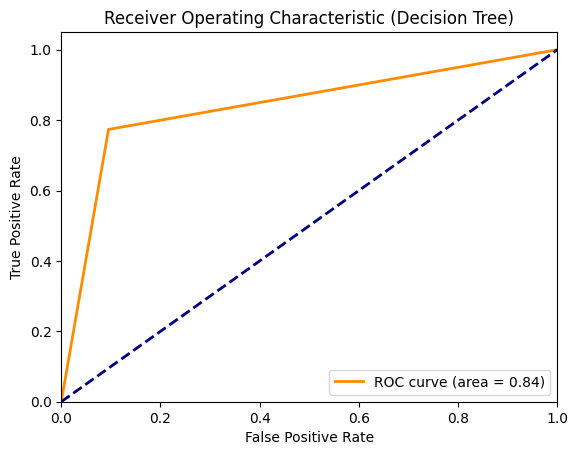

In [81]:
# Plot ROC curve for Decision Tree
from sklearn.metrics import roc_curve, auc

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_y_pred)
dt_roc_auc = auc(dt_fpr, dt_tpr)

plt.figure()
plt.plot(dt_fpr, dt_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Decision Tree)')
plt.legend(loc="lower right")
plt.show()

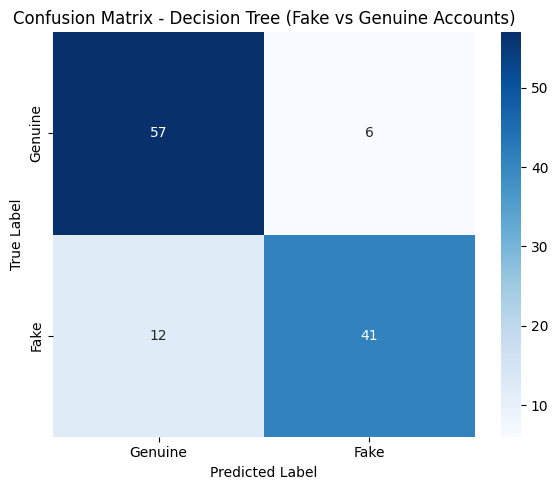

In [82]:
# Plot Confusion Matrix heatmap for Decision Tree
dt_con_matrix = confusion_matrix(y_test, dt_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(dt_con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Fake vs Genuine Accounts)')
plt.tight_layout()
plt.show()

In [83]:
# Make predictions with the Decision Tree model
dt_y_pred = dt_model.predict(X_test_scaled)

In [84]:
# Evaluate Decision Tree Classifier
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, dt_y_pred))
print("Classification Report (Decision Tree):\n", classification_report(y_test, dt_y_pred))

Confusion Matrix (Decision Tree):
 [[57  6]
 [12 41]]
Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86        63
           1       0.87      0.77      0.82        53

    accuracy                           0.84       116
   macro avg       0.85      0.84      0.84       116
weighted avg       0.85      0.84      0.84       116



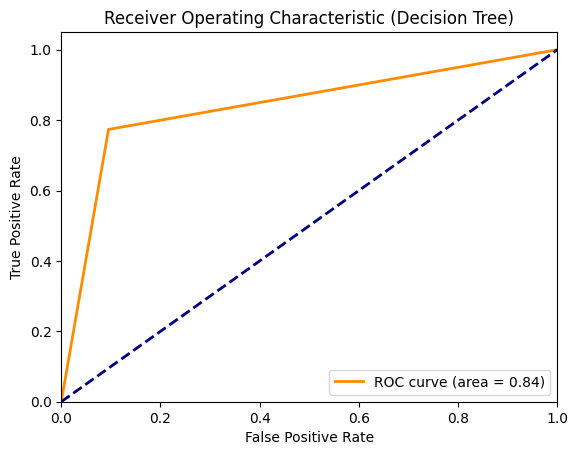

In [85]:
# Plot ROC curve for Decision Tree
from sklearn.metrics import roc_curve, auc

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_y_pred)
dt_roc_auc = auc(dt_fpr, dt_tpr)

plt.figure()
plt.plot(dt_fpr, dt_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Decision Tree)')
plt.legend(loc="lower right")
plt.show()

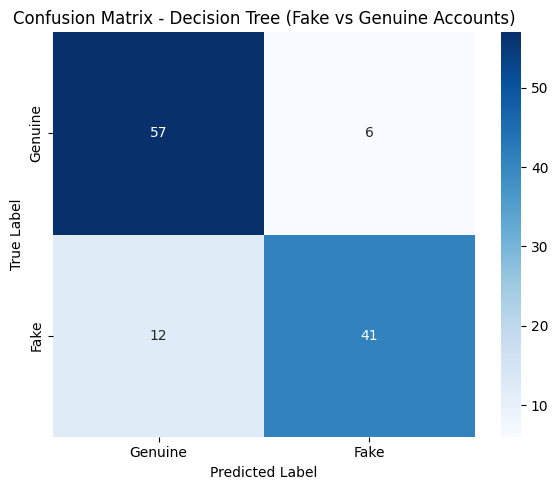

In [86]:
# Plot Confusion Matrix heatmap for Decision Tree
dt_con_matrix = confusion_matrix(y_test, dt_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(dt_con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Fake vs Genuine Accounts)')
plt.tight_layout()
plt.show()

In [87]:
# Make predictions with the Decision Tree model
dt_y_pred = dt_model.predict(X_test_scaled)

In [88]:
# Evaluate Decision Tree Classifier
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, dt_y_pred))
print("Classification Report (Decision Tree):\n", classification_report(y_test, dt_y_pred))

Confusion Matrix (Decision Tree):
 [[57  6]
 [12 41]]
Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86        63
           1       0.87      0.77      0.82        53

    accuracy                           0.84       116
   macro avg       0.85      0.84      0.84       116
weighted avg       0.85      0.84      0.84       116



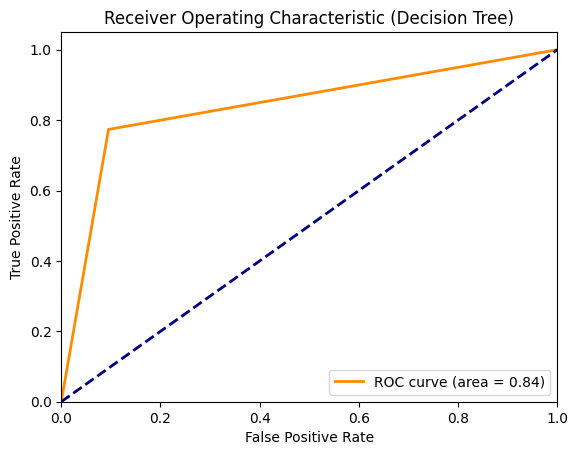

In [89]:
# Plot ROC curve for Decision Tree
from sklearn.metrics import roc_curve, auc

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_y_pred)
dt_roc_auc = auc(dt_fpr, dt_tpr)

plt.figure()
plt.plot(dt_fpr, dt_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Decision Tree)')
plt.legend(loc="lower right")
plt.show()

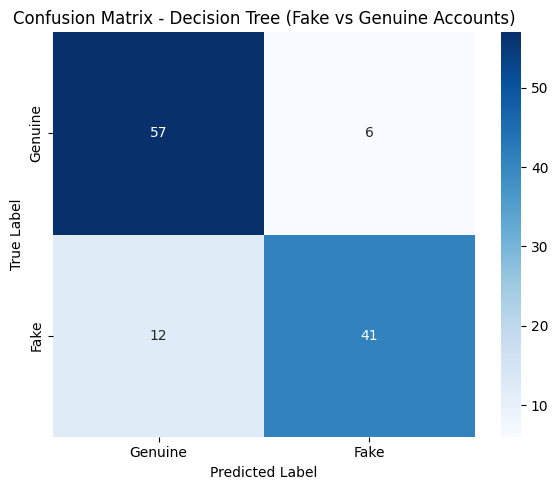

In [90]:
# Plot Confusion Matrix heatmap for Decision Tree
dt_con_matrix = confusion_matrix(y_test, dt_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(dt_con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Fake vs Genuine Accounts)')
plt.tight_layout()
plt.show()

In [91]:
# Make predictions with the Decision Tree model
dt_y_pred = dt_model.predict(X_test_scaled)

In [92]:
# Evaluate Decision Tree Classifier
print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, dt_y_pred))
print("Classification Report (Decision Tree):\n", classification_report(y_test, dt_y_pred))

Confusion Matrix (Decision Tree):
 [[57  6]
 [12 41]]
Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.83      0.90      0.86        63
           1       0.87      0.77      0.82        53

    accuracy                           0.84       116
   macro avg       0.85      0.84      0.84       116
weighted avg       0.85      0.84      0.84       116



In [95]:
# Make predictions with the Random Forest model
rf_y_pred = rf.predict(X_test_scaled)

In [96]:
# Evaluate Random Forest Classifier
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix (Random Forest):\n", confusion_matrix(y_test, rf_y_pred))
print("Classification Report (Random Forest):\n", classification_report(y_test, rf_y_pred))

Confusion Matrix (Random Forest):
 [[61  2]
 [11 42]]
Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.85      0.97      0.90        63
           1       0.95      0.79      0.87        53

    accuracy                           0.89       116
   macro avg       0.90      0.88      0.88       116
weighted avg       0.90      0.89      0.89       116



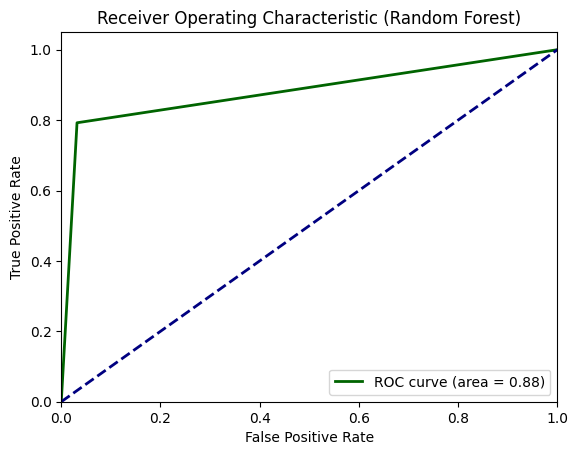

In [97]:
# Plot ROC curve for Random Forest
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_pred)
rf_roc_auc = auc(rf_fpr, rf_tpr)

plt.figure()
plt.plot(rf_fpr, rf_tpr, color='darkgreen', lw=2, label='ROC curve (area = %0.2f)' % rf_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Random Forest)')
plt.legend(loc="lower right")
plt.show()

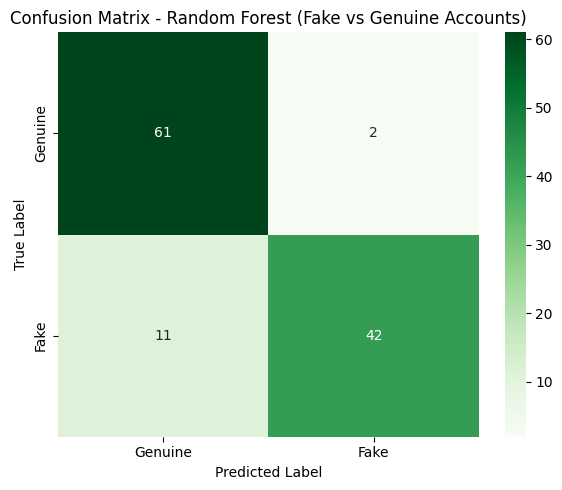

In [98]:
# Plot Confusion Matrix heatmap for Random Forest
import seaborn as sns

rf_con_matrix = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(rf_con_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest (Fake vs Genuine Accounts)')
plt.tight_layout()
plt.show()

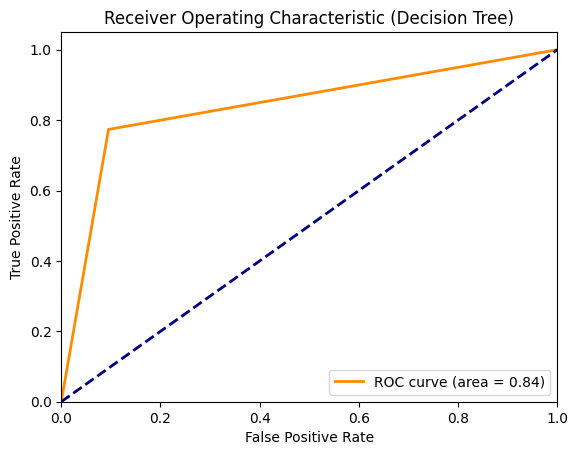

In [93]:
# Plot ROC curve for Decision Tree
from sklearn.metrics import roc_curve, auc

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_y_pred)
dt_roc_auc = auc(dt_fpr, dt_tpr)

plt.figure()
plt.plot(dt_fpr, dt_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Decision Tree)')
plt.legend(loc="lower right")
plt.show()

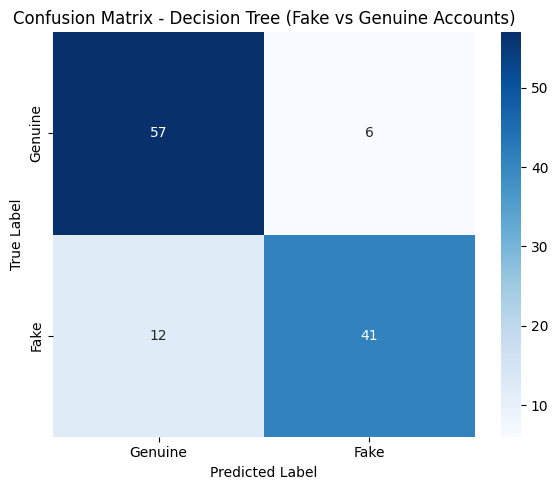

In [94]:
# Plot Confusion Matrix heatmap for Decision Tree
dt_con_matrix = confusion_matrix(y_test, dt_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(dt_con_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree (Fake vs Genuine Accounts)')
plt.tight_layout()
plt.show()

**Future Corrections**:

The confusion matrix reveals that the model tends to favor predicting fake accounts, likely due to class imbalance or limited representation of genuine accounts in the training data. This resulted in many genuine accounts being misclassified.

To improve the model, future work may include:

*  Balancing the training dataset using techniques like SMOTE or class weighting

*  Feature engineering with more behavioral attributes

*  Exploring more complex architectures or ensemble methods

Despite the modest accuracy, the model demonstrates potential in identifying fake accounts with high recall. This makes it particularly useful for screening potentially fake users, though further refinement is needed for real-world deployment.